In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# PyTesseract Testing

In [2]:
!apt install tesseract-ocr -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libarchive13 libgif7 liblept5 libtesseract5 tesseract-ocr-eng
  tesseract-ocr-osd
Suggested packages:
  lrzip
The following NEW packages will be installed:
  libarchive13 libgif7 liblept5 libtesseract5 tesseract-ocr tesseract-ocr-eng
  tesseract-ocr-osd
0 upgraded, 7 newly installed, 0 to remove and 0 not upgraded.
Need to get 7706 kB of archives.
After this operation, 24.4 MB of additional disk space will be used.
Get:1 http://deb.debian.org/debian bookworm/main amd64 libarchive13 amd64 3.6.2-1+deb12u2 [343 kB]
Get:2 http://deb.debian.org/debian bookworm/main amd64 libgif7 amd64 5.2.1-2.5 [46.9 kB]
Get:3 http://deb.debian.org/debian bookworm/main amd64 liblept5 amd64 1.82.0-3+b3 [1050 kB]
Get:4 http://deb.debian.org/debian bookworm/main amd64 libtesseract5 amd64 5.3.0-2 [1279 kB]
Get:5 http://deb.debian.org/debian bookworm/main amd64 t

In [3]:
pip install pytesseract


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
root = "/kaggle/input/musait/basket/"

## Basic usage in python

In [5]:
import pytesseract
from PIL import Image

# Load image
img = Image.open(root+"negative_022.jpg")

# OCR
text = pytesseract.image_to_string(img)

print(text)

7 , , )
” «NEWS SPECIAL REPORT ——
i) TWO BOMB EXPLOSIONS AT e
I, THE BOSTON MARATHON

— §6idag f



## Using with openCV (for preprocessing)

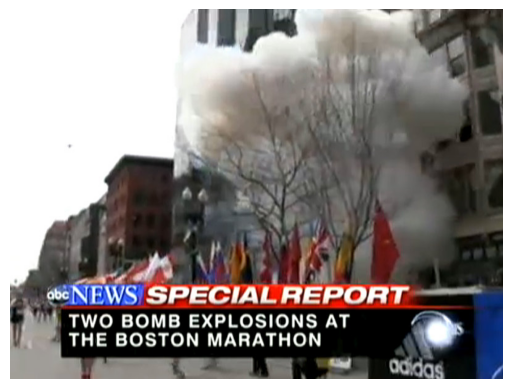

j

N
ere ¥ i t

,. &NEWS! SPECIAL REPORT ——

tis BOMB EXPLOSIONS AT ee
THE BOSTON MARATHON

3, = Oidos




In [6]:
import cv2
import pytesseract
from matplotlib import pyplot as plt


# Read image using OpenCV
img = cv2.imread(root+"negative_022.jpg")

# Print the image
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB for correct colors

plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

# Optional: convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# OCR
text = pytesseract.image_to_string(gray, lang='eng')

print(text)

## Txt-Img Low Confidence Bounding Boxes

In [19]:
# Get OCR with bounding boxes
d = pytesseract.image_to_data(gray, output_type=pytesseract.Output.DICT)

In [20]:
d['level']

[1, 2, 3, 4, 5, 5, 4, 5, 5, 5, 2, 3, 4, 5, 5, 5, 2, 3, 4, 5, 4, 5]

In [ ]:
# Example: draw boxes
n_boxes = len(d['level'])
for i in range(n_boxes):
    (x, y, w, h) = (d['left'][i], d['top'][i], d['width'][i], d['height'][i])
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

cv2.imwrite('boxed_output.jpg', img)

True

## Extract words individually

In [11]:
for i in range(n_boxes):
    word = d['text'][i]
    if word.strip() != '':
        print(f"Word: {word}, Conf: {d['conf'][i]}, Box: ({d['left'][i]}, {d['top'][i]})")

Word: j, Conf: 80, Box: (286, 363)
Word: Wii, Conf: 22, Box: (306, 381)
Word: ee, Conf: 20, Box: (87, 428)
Word: At, Conf: 71, Box: (199, 391)
Word: \, Conf: 19, Box: (310, 410)
Word: a, Conf: 45, Box: (426, 435)
Word: f:, Conf: 0, Box: (470, 405)
Word: ,., Conf: 24, Box: (1, 470)
Word: %&, Conf: 2, Box: (76, 443)
Word: NEWS!), Conf: 21, Box: (99, 447)
Word: SPECIAL, Conf: 95, Box: (221, 449)
Word: REPORT", Conf: 0, Box: (439, 449)
Word: i), Conf: 73, Box: (44, 490)
Word: TWO, Conf: 95, Box: (96, 495)
Word: BOMB, Conf: 96, Box: (182, 495)
Word: EXPLOSIONS, Conf: 96, Box: (291, 495)
Word: AT, Conf: 96, Box: (512, 495)
Word: ee, Conf: 20, Box: (651, 493)
Word: |, Conf: 60, Box: (0, 510)
Word: THE, Conf: 96, Box: (96, 525)
Word: BOSTON, Conf: 96, Box: (172, 525)
Word: MARATHON, Conf: 95, Box: (321, 525)
Word: i, Conf: 27, Box: (665, 520)
Word: a, Conf: 47, Box: (96, 569)
Word: =, Conf: 35, Box: (519, 567)
Word: §6Oidas, Conf: 20, Box: (616, 570)


## Txt-Img High Confidence Bounding Box

[221, 96, 182, 291, 512, 96, 172, 321]
[449, 495, 495, 495, 495, 525, 525, 525]
[432, 166, 275, 497, 550, 156, 304, 503]
[478, 517, 517, 517, 516, 547, 547, 547]
96 550
449 547


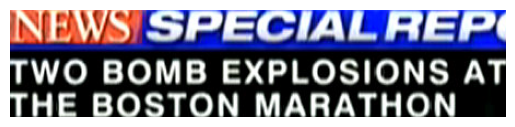

Saved cropped region: cropped_high_conf_region.jpg


In [12]:
import cv2
import pytesseract

# Load image
img = cv2.imread(root+"negative_022.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Get detailed OCR output
data = pytesseract.image_to_data(gray, output_type=pytesseract.Output.DICT)

# Collect high-confidence bounding boxes
x_list, y_list, x2_list, y2_list = [], [], [], []

for i in range(len(data['text'])):
    text = data['text'][i].strip()
    conf = data['conf'][i]  # Already int

    if text != "" and conf > 90:
        x, y, w, h = data['left'][i], data['top'][i], data['width'][i], data['height'][i]
        x_list.append(x)
        y_list.append(y)
        x2_list.append(x + w)
        y2_list.append(y + h)
        # print(x_list)

print(x_list)
print(y_list)
print(x2_list)
print(y2_list)
# Check if any valid boxes found
if x_list:
    # Calculate the union bounding box around all high-confidence words
    x_min, y_min = min(x_list), min(y_list)
    x_max, y_max = max(x2_list), max(y2_list)
    print(x_min,x_max)
    print(y_min,y_max)

    # Draw the single high-confidence bounding box
    img_boxed = img.copy()
    cv2.rectangle(img_boxed, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
    cv2.imwrite("high_confidence_box.jpg", img_boxed)

    # Crop and save just the high-confidence region
    cropped = img[y_min:y_max, x_min:x_max]
    cv2.imwrite("cropped_high_conf_region.jpg", cropped)
    plt.imshow(cropped)
    plt.axis("off")
    plt.show()
    print(f"Saved cropped region: cropped_high_conf_region.jpg")
else:
    print("No high-confidence (>90) text regions found.")

# PyTesseract Text-Image Extraction

## High Confidence Boxes

In [15]:
files = os.listdir(root)
files.sort()

columns = ["filename", "filepath", "text-detected", "OCR", "coordinates", "sentiment"]
ocr_hc = pd.DataFrame(columns=columns)

In [16]:
root

'/kaggle/input/musait/basket/'

In [ ]:
def get_bounding_boxes(data, x_list, y_list, x2_list, y2_list):
    # Check if any valid boxes found
    if not x_list:
        return []
    
        # Calculate bounding box union
        x_min, y_min = min(x_list), min(y_list)
        x_max, y_max = max(x2_list), max(y2_list)
    
        # Draw rectangle on a copy of the image
        boxed_image = image.copy()
        draw = ImageDraw.Draw(boxed_image)
        draw.rectangle([x_min, y_min, x_max, y_max], outline="green", width=2)
        boxed_image.save("high_confidence_box.jpg")
    
        # Crop and save the high-confidence region
        cropped = image.crop((x_min, y_min, x_max, y_max))
        cropped.save("cropped_high_conf_region.jpg")
    
        # Show cropped region
        plt.imshow(cropped)
        plt.axis("off")
        plt.show()
        print(f"Saved cropped region: cropped_high_conf_region.jpg")

700 704
174 204


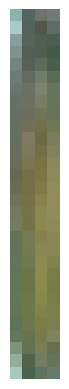

Saved cropped region: hc-txt-img/txt-img_negative_001.jpg


In [17]:
import os
import cv2
import pytesseract
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

# Path to folder containing images
# image_folder = "file"  # folder containing image files
output_folder = "hc-txt-img"
os.makedirs(output_folder, exist_ok=True)

# files = ["negative_022.jpg"]

count = 0

# Traverse all image files in folder
for file in files:
    # if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
    filepath = os.path.join(root, file)
    sentiment = file.split('_')[0]  # Assuming format: sentiment_001.jpg

    img = cv2.imread(filepath)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    data = pytesseract.image_to_data(gray, output_type=pytesseract.Output.DICT)

    x_list, y_list, x2_list, y2_list = [], [], [], []
    # detected_texts = []
    coordinates = []
    flag = 0 # flag 0 for no text detected

    for i in range(len(data['text'])):
        text = data['text'][i].strip()
        conf = data['conf'][i]  # Already int
    
        if text != "" and conf > 90:
            x, y, w, h = data['left'][i], data['top'][i], data['width'][i], data['height'][i]
            x_list.append(x)
            y_list.append(y)
            x2_list.append(x + w)
            y2_list.append(y + h)
            # print(x_list)
    
    # Check if any valid boxes found
    if x_list:
        # Calculate the union bounding box around all high-confidence words
        x_min, y_min = min(x_list), min(y_list)
        x_max, y_max = max(x2_list), max(y2_list)
        print(x_min,x_max)
        print(y_min,y_max)

        coordinates = [{
            'x_min':x_min,
            'y_max':y_max,
            'y_min':y_min,
            'x_max':x_max,
        }]
    
        # Draw the single high-confidence bounding box
        img_boxed = img.copy()
        cv2.rectangle(img_boxed, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
        cv2.imwrite("high_confidence_box.jpg", img_boxed)
    
        # Crop and save just the high-confidence region
        cropped = img[y_min:y_max, x_min:x_max]
        cropped_path = output_folder+"/"+"txt-img_"+file
        cv2.imwrite(cropped_path, cropped)
        plt.imshow(cropped)
        plt.axis("off")
        plt.show()
        print(f"Saved cropped region: {cropped_path}")
    else:
        print("No high-confidence (>90) text regions found.")
    ocr_hc.loc[count] = [file, filepath, flag, text, coordinates, file.split("_")[0]]
    count+=1
    break

# Pytesseract OCR Extraction

In [21]:
def get_pytesseract_ocr(img):
    # client = vision.ImageAnnotatorClient()
    # image = vision.Image(content=content)

    # Perform OCR (Text Detection)
    # response = client.text_detection(image=image)
    # texts = response.text_annotations
    texts = pytesseract.image_to_string(img)
    # texts[0] contains all info about the entire line of detected text
    # texts[0].description contains the entire line of detected text
    
    return texts

In [22]:
print("Number of files =",len(os.listdir(root)))

Number of files = 2875


In [32]:
files = os.listdir(root)
files.sort()

columns = ["filename", "filepath", "text-detected", "OCR", "sentiment"]
ocr_pyt = pd.DataFrame(columns=columns)

In [33]:
root

'/kaggle/input/musait/basket/'

In [34]:
ocr_pyt

,filename,filepath,text-detected,OCR,sentiment


In [35]:
# from tqdm import tqdm
# import cv2
count = 0


# for file in tqdm(files, desc="Extracting OCR from files"):
for file in files:
    # filepath = root+"/"+file
    filepath = root+file
    print(filepath)
    # break

    # Read image using OpenCV
    img = cv2.imread(filepath)

    # Optional: convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # plt.imshow(gray)

    # OCR
    ocr = pytesseract.image_to_string(gray)
    # print(ocr)
    flag = 0 if not ocr else 1 # text detection flag
    
    ocr_pyt.loc[count] = [file, filepath, flag, ocr, file.split("_")[0]]
    count+=1
    # break

/kaggle/input/musait/basket/negative_001.jpg
/kaggle/input/musait/basket/negative_002.jpg
/kaggle/input/musait/basket/negative_003.jpg
/kaggle/input/musait/basket/negative_004.jpg
/kaggle/input/musait/basket/negative_005.jpg
/kaggle/input/musait/basket/negative_006.jpg
/kaggle/input/musait/basket/negative_007.jpg
/kaggle/input/musait/basket/negative_008.jpg
/kaggle/input/musait/basket/negative_009.jpg
/kaggle/input/musait/basket/negative_010.jpg
/kaggle/input/musait/basket/negative_011.jpg
/kaggle/input/musait/basket/negative_012.jpg
/kaggle/input/musait/basket/negative_013.jpg
/kaggle/input/musait/basket/negative_014.jpg
/kaggle/input/musait/basket/negative_015.jpg
/kaggle/input/musait/basket/negative_016.jpg
/kaggle/input/musait/basket/negative_017.jpg
/kaggle/input/musait/basket/negative_018.jpg
/kaggle/input/musait/basket/negative_019.jpg
/kaggle/input/musait/basket/negative_020.jpg
/kaggle/input/musait/basket/negative_021.jpeg
/kaggle/input/musait/basket/negative_022.jpg
/kaggle/i

libpng warning: iCCP: known incorrect sRGB profile


/kaggle/input/musait/basket/neutral_244.png


libpng warning: iCCP: known incorrect sRGB profile


/kaggle/input/musait/basket/neutral_245.jpeg
/kaggle/input/musait/basket/neutral_246.jpeg
/kaggle/input/musait/basket/neutral_247.jpg
/kaggle/input/musait/basket/neutral_248.jpg
/kaggle/input/musait/basket/neutral_249.jpeg
/kaggle/input/musait/basket/neutral_250.jpg
/kaggle/input/musait/basket/neutral_251.jpg
/kaggle/input/musait/basket/neutral_252.jpeg
/kaggle/input/musait/basket/neutral_253.jpeg
/kaggle/input/musait/basket/neutral_254.jpg
/kaggle/input/musait/basket/neutral_255.jpg
/kaggle/input/musait/basket/neutral_256.jpeg
/kaggle/input/musait/basket/neutral_257.jpeg
/kaggle/input/musait/basket/neutral_258.jpg
/kaggle/input/musait/basket/neutral_259.jpeg
/kaggle/input/musait/basket/neutral_260.jpeg
/kaggle/input/musait/basket/neutral_261.jpg
/kaggle/input/musait/basket/neutral_262.jpeg
/kaggle/input/musait/basket/neutral_263.jpeg
/kaggle/input/musait/basket/neutral_264.jpg
/kaggle/input/musait/basket/neutral_265.jpg
/kaggle/input/musait/basket/neutral_266.jpeg
/kaggle/input/musait

In [15]:
print(dir(pytesseract))

['ALTONotSupported', 'Output', 'TSVNotSupported', 'TesseractError', 'TesseractNotFoundError', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'get_languages', 'get_tesseract_version', 'image_to_alto_xml', 'image_to_boxes', 'image_to_data', 'image_to_osd', 'image_to_pdf_or_hocr', 'image_to_string', 'pytesseract', 'run_and_get_multiple_output', 'run_and_get_output']


In [36]:
ocr_pyt

,filename,filepath,text-detected,OCR,sentiment
0,negative_001.jpg,/kaggle/input/musait/basket/negative_001.jpg,1,fStop Wak\niv UKRATNE Po\n\nConte Yxpaini |\n\n,negative
1,negative_002.jpg,/kaggle/input/musait/basket/negative_002.jpg,1,NEW ee V\nNIGHTLY ATS =e ord a.\n,negative
2,negative_003.jpg,/kaggle/input/musait/basket/negative_003.jpg,0,,negative
3,negative_004.jpg,/kaggle/input/musait/basket/negative_004.jpg,0,,negative
4,negative_005.jpg,/kaggle/input/musait/basket/negative_005.jpg,1,NEW ee V\nNIGHTLY ATS =e ord a.\n,negative
...,...,...,...,...,...
2870,positive_995.jpg,/kaggle/input/musait/basket/positive_995.jpg,1,—— es\n\n“Just keep taking\nchances and\nhavin...,positive
2871,positive_996.jpg,/kaggle/input/musait/basket/positive_996.jpg,1,"°Never regret anything\n\nthat made you smile,...",positive
2872,positive_997.jpg,/kaggle/input/musait/basket/positive_997.jpg,0,,positive
2873,positive_998.jpg,/kaggle/input/musait/basket/positive_998.jpg,1,OF COURSE IT’S HARD.\nIT’S SUPPOSED TO BE\nHAR...,positive


In [37]:
ocr_pyt.to_csv("pyt-ocr.csv", index=False)